# Accessing Data using Python

This notebook covers the common task of collecting data efficiently using Python. It complements `Security_Returns_Properties.ipynb`, which showed how to pull equity price data from Yahoo! Finance. Here we broaden the toolkit, with examples covering:

- Reading data from a local Excel workbook (the Goyal-Welch equity premium predictor dataset)
- Downloading macroeconomic data from FRED and portfolio/factor data from Kenneth French's data library, via the `pandas_datareader` package
- Pulling data from WRDS -- CRSP and Compustat

There are many other data sources beyond those covered here, but the goal is to build transferable skills that will help you access alternative sources as needed for your own research.

*Note: I may add more examples to this notebook as the semester proceeds, so you may wish to check back for updates.*

*Acknowledgment*: This notebook was produced with the assistance of AI. I remain responsible for the content and any errors.

## Learning Objectives

By the end of this notebook, you should be able to:

1. Read data from an Excel workbook into a pandas DataFrame, including selecting a specific worksheet.
2. Use the `pandas_datareader` package to download macroeconomic time series directly from FRED.
3. Compute growth rates and inflation rates from downloaded level data, and produce a properly labeled, accessible time-series plot.
4. Download portfolio-return and factor data directly from Kenneth French's data library.
5. Describe what WRDS, CRSP, and Compustat provide, and outline how a Compustat SQL query is structured and reshaped into a firm-year panel.

## Instructions to Run

**Data:** This notebook uses one local file, `data/GWPredictorData2024.xlsx` -- the Goyal-Welch equity premium predictor dataset -- which is already included in the course repository's `data/` folder (a small, redistributable extract). It's also posted on the course Canvas site under Data, in case you'd rather grab it from there. The FRED and Kenneth French examples pull data live over the internet via `pandas_datareader`; **an internet connection is required** for those sections. The WRDS/Compustat section requires a WRDS account -- a classroom account is being set up for this course, and login details will be shared once it's ready; if you already have your own WRDS credentials, those work too. That section's code has not been executed in this notebook, since it needs an interactive login.

**If your data lives somewhere else:** the Excel file is read via `pd.read_excel('../data/GWPredictorData2024.xlsx', ...)`, assuming this notebook lives in `notebooks/` and `data/` is a sibling folder. Edit that path if you keep the file elsewhere.

**Package dependencies:** `os`, `numpy`, `pandas`, `matplotlib`, `pandas_datareader`, `openpyxl` (needed by pandas to read `.xlsx` files), and `wrds` -- all standard Anaconda packages except `pandas_datareader` and `wrds`. Otherwise: `pip install pandas numpy matplotlib pandas_datareader openpyxl wrds`.

**Viewing the HTML export in Canvas:** If equations show up as raw LaTeX source (e.g., `$...$`) instead of typeset math, don't use Canvas's built-in file preview -- download the file and open it locally in a browser instead.

## Reading Excel data: the Goyal-Welch dataset

Academic researchers often maintain datasets from research articles online, and sometimes update and extend these datasets. A very useful example is the "Goyal-Welch" dataset from an influential 2008 journal [article](https://academic.oup.com/rfs/article-abstract/21/4/1455/1565737) by Amit Goyal and Ivo Welch. The article asks whether the "equity premium" -- the average return on a broad stock market index relative to the risk-free rate -- varies over time, and if so what variables best capture this variation. The main point made by the article is that many apparent "predictors" of the equity premium studied in prior literature did not perform well using an "out-of-sample" research design. We will discuss this topic in detail in `Equity_Premium_Inference.ipynb`.

For now, we just use the dataset as a concrete example of pulling data from Excel files (CSV is similar). The current data is available from Amit Goyal's webpage; a static copy is included in this repository's `data/` folder (and also posted on Canvas), so the code below will work without any setup on your part.

The Goyal-Welch dataset contains monthly, quarterly, and annual data that enable computation of stock index (excess) returns, as well as observations on a range of variables that have been conjectured to capture variation in the equity premium.

The code below illustrates how to read in the monthly data. The code can easily be adapted to read the quarterly or annual versions of the data as well.

In [1]:
import os
import warnings
import pandas as pd

# Openpyxl emits a harmless warning about this workbook's header/footer formatting; suppress it.
warnings.filterwarnings('ignore', category=UserWarning, module='openpyxl')

# The Excel file lives in the course repo's data/ folder, as a sibling to notebooks/
filepath = os.path.join('..', 'data', 'GWPredictorData2024.xlsx')

# Note: the default is to read the 1st sheet of an excel file (counted as 0) -- but for this
# spreadsheet the first sheet is an info sheet, so we want sheet_name=1 (the monthly data)
gwdata = pd.read_excel(filepath, header=0, sheet_name=1)
gwdata.tail(10)

,yyyymm,price,d12,e12,ret,retx,AAA,BAA,lty,ltr,...,ygap,rdsp,rsvix,gpce,gip,tchi,house,avgcor,shtint,disag
1838,202403,5254.35,70.824826,191.390000,0.032211,0.031069,0.0501,0.0575,0.0421,0.006426,...,-3.353736,0.033261,NaN,NaN,NaN,1.055849,NaN,0.166170,-2.151200,3.260390
1839,202404,5035.69,71.208484,192.903333,-0.039800,-0.040584,0.0528,0.0600,0.0454,-0.023274,...,-3.306516,0.031228,NaN,NaN,NaN,1.055849,NaN,0.179997,-2.175105,2.870623
1840,202405,5277.51,71.592142,194.416667,0.049431,0.047890,0.0525,0.0595,0.0448,0.014568,...,-3.345032,0.033616,NaN,NaN,NaN,1.055849,NaN,0.170374,-2.123416,3.660209
1841,202406,5460.48,71.975800,195.930000,0.037199,0.036012,0.0513,0.0582,0.0431,0.010085,...,-3.369732,0.032274,NaN,NaN,NaN,1.055849,NaN,0.143822,-1.761255,2.717360
1842,202407,5522.30,72.450633,197.376667,0.012148,0.011297,0.0512,0.0584,0.0425,0.021879,...,-3.373057,0.049683,NaN,NaN,NaN,1.055849,NaN,0.112621,-1.990578,2.608594
1843,202408,5648.40,72.925466,198.823333,0.024283,0.022898,0.0487,0.0560,0.0387,0.012792,...,-3.384681,0.034581,NaN,NaN,NaN,1.055849,NaN,0.195877,-1.884540,2.504554
1844,202409,5762.48,73.400300,200.270000,0.022821,0.021707,0.0468,0.0542,0.0372,0.012023,...,-3.395982,0.023585,NaN,NaN,NaN,1.055849,NaN,0.236572,-2.006363,2.263729
1845,202410,5705.45,73.877618,203.570000,-0.008690,-0.009523,0.0495,0.0563,0.0410,-0.023811,...,-3.373349,0.029564,NaN,NaN,NaN,1.055849,NaN,0.256120,-2.057976,2.846782
1846,202411,6032.38,74.354936,206.870000,0.060420,0.059016,0.0514,0.0578,0.0436,0.007772,...,-3.415483,0.040457,NaN,NaN,NaN,1.055849,NaN,0.176644,-2.078823,3.231256
1847,202412,5881.63,74.832255,210.170000,-0.023445,-0.024621,0.0520,0.0580,0.0439,-0.015408,...,-3.374636,0.029925,NaN,NaN,NaN,1.055849,NaN,0.195351,-2.135697,2.824905


A quick data dictionary for some of the key columns:

- yyyymm: year and month
- D12: sum of past 12 months dividends (aggregate)
- E12: sum of past 12 months earnings (aggregate)
- b/m: book-market ratio
- tbl: Treasury bill rate (decimal)
- AAA: average yield on AAA-rated corporate bonds (decimal)
- BAA: average yield on BAA-rated corporate bonds (decimal)
- lty: yield on long-term Treasury bonds (decimal)
- ntis: a measure of net issuance by firms
- Rfree: proxy for the risk-free rate prevailing at the time (decimal)
- infl: inflation rate (decimal)
- ltr: return on a portfolio of long-term government bonds
- corpr: return on a portfolio of corporate bonds
- svar: a measure of stock return variance
- CRSP_SPvw: return on S&P 500 portfolio (sourced from CRSP, decimal)
- CRSP_SPvwx: return on S&P 500 portfolio excluding the dividend component of returns (decimal)

The full dataset contains 57 columns -- more predictors than are worth listing here. The workbook's first worksheet contains descriptive information about every variable included, so consult that if you need a column not listed above.

Below is an example of reading in data from a different worksheet (the annual data):

In [2]:
# Now suppose we want to read the annual data instead (sheet_name=3)
gwdata_annual = pd.read_excel(filepath, header=0, sheet_name=3)
gwdata_annual.head()

,yyyy,price,d12,e12,ret,retx,AAA,BAA,lty,ltr,...,ygap,rdsp,rsvix,gpce,gip,tchi,house,avgcor,shtint,disag
0,1871,4.74,0.26,0.40,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1872,5.07,0.30,0.43,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1873,4.42,0.33,0.46,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1874,4.54,0.33,0.46,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1875,4.37,0.30,0.36,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


We will analyze the Goyal-Welch data in further detail in `Equity_Premium_Inference.ipynb`. For now, let's shift gears and illustrate how to use the `pandas_datareader` package to pull in various types of data in relatively straightforward fashion.

## Using the `pandas_datareader` package

`pandas_datareader` is a Python package that lets us build a pandas DataFrame directly from various online data sources, without manually downloading and reformatting files.

Below are a number of examples that use the package to download various data series. Detailed documentation for the package is available [here](https://pandas-datareader.readthedocs.io/en/latest/index.html).

### Downloading macroeconomic data from FRED

The first example involves downloading macroeconomic data from the [FRED site](https://fred.stlouisfed.org/) maintained by the St. Louis Fed. It is possible to download data directly from the web interface, but doing so via Python is more efficient and helps with research replicability.

We will begin by downloading data for US quarterly gross domestic product (GDP) from 2002 through the present.

In [3]:
import numpy as np
import pandas as pd
import pandas_datareader.data as web
import datetime as dt
import warnings
# Avoid being inundated with a deprecation warning pandas_datareader currently emits internally
warnings.filterwarnings('ignore')

# Set start and end dates for data collection (these can obviously be changed)
start = dt.datetime(2002, 1, 1)
end = dt.datetime.today()

# As an example, download the quarterly 'GDP' series from FRED:
gdp = web.DataReader('GDP', 'fred', start, end)
# Note: the first argument to DataReader is the data series, the second is the source (FRED here)

gdp.tail(20)

,GDP
DATE,
2021-07-01,23982.379
2021-10-01,24813.600
2022-01-01,25250.347
2022-04-01,25861.292
2022-07-01,26336.304
2022-10-01,26770.514
2023-01-01,27216.445
2023-04-01,27530.055
2023-07-01,28074.846


Going to FRED's website, we can look up that the "GDP" series corresponds to the seasonally-adjusted level of nominal GDP, measured in billions of dollars (annual rate). So a reported value of, say, 29723.864 means annualized US GDP of around \$29.7 trillion/year for that quarter.

*Careful with dates!* What does a date like `2024-10-01` mean, actually -- Q3 2024 or Q4 2024? This is not obvious from the label alone. A good way to check is to look at a quarter where we know (roughly) what happened, specifically Q2 2020, when GDP fell precipitously due to COVID. Looking at the output above, `2020-04-01` is the row showing that sharp decline, so `2020-04-01` must be Q2 2020. By the same logic, `2024-10-01` means Q4 2024. In short, the dates correspond to the *beginning* of each quarter.

Often, we are less interested in the *level* of GDP than in the *growth rate*. The growth rate can be defined in several ways. One simple approach is to take the percent change from the prior quarter. This can be done easily in Python using pandas' `pct_change` functionality:

In [4]:
gdpchange = 100 * gdp.pct_change()
# Note: multiplied by 100 to express the values as percentages

gdpchange.tail(20)
# Checking the last several observations to be sure things are reasonable -- as expected there
# is a big negative change around Q2 2020 (COVID), followed by a sharp rebound.

,GDP
DATE,
2021-07-01,2.375442
2021-10-01,3.465966
2022-01-01,1.760111
2022-04-01,2.419551
2022-07-01,1.836768
2022-10-01,1.648713
2023-01-01,1.665754
2023-04-01,1.152281
2023-07-01,1.978895


What if we want to download more than one series at a time? The following example illustrates how to do this, using two alternative measures of inflation:

1. CPIAUCSL = Consumer Price Index for All Urban Consumers: All Items in U.S. City Average (monthly, seasonally adjusted)
2. CPILFESL = Consumer Price Index for All Urban Consumers: All Items Less Food and Energy in U.S. City Average (monthly, seasonally adjusted)

These are two out of many possible inflation measures. Both focus on U.S. cities, in contrast to some other variants that include all areas. The big difference between the two is the exclusion of food and energy components in the second version. We will (very briefly) explore the difference this makes below.

*Note: even when we use Python to pull data from FRED, the website (link above) remains useful for verifying series definitions, so that we can be sure we have the particular series we want.*

In [5]:
cpi = web.DataReader(['CPIAUCSL', 'CPILFESL'], 'fred', start, end)
cpi.tail(20)

,CPIAUCSL,CPILFESL
DATE,,
2024-12-01,317.604,323.259
2025-01-01,318.961,324.638
2025-02-01,319.679,325.465
2025-03-01,319.785,325.690
2025-04-01,320.302,326.467
2025-05-01,320.620,326.893
2025-06-01,321.435,327.658
2025-07-01,322.169,328.682
2025-08-01,323.291,329.700


As with GDP, it is more common to focus on *rates* of inflation than on the CPI level. There are two common ways to compute an inflation rate from monthly CPI data, and they can tell noticeably different stories:

- **Year-over-year (YoY):** the percent change from the same month one year ago, i.e., $100 \times (CPI_t / CPI_{t-12} - 1)$. This is what's typically quoted in the financial press and by the Fed/BLS (e.g., "CPI rose 3.1% year-over-year"). Spanning a full year effectively smooths over month-to-month noise.
- **Annualized month-over-month (MoM):** the percent change from the *previous* month, annualized by multiplying by 12. This reacts faster to the most recent data, but is considerably noisier -- a single unusual month gets amplified by the annualization.

Because our downloaded CPI levels are already seasonally adjusted, both measures are meaningful as computed here. (With a non-seasonally-adjusted series, YoY still works fine -- comparing the same calendar month a year apart cancels out seasonal effects -- but the MoM measure would need seasonal adjustment first.)

The code below computes both series for headline and core CPI, and plots them together so you can see directly how much smoother YoY is relative to annualized MoM. Either way, the same general lesson comes through: food and energy prices are much more volatile than the rest of the CPI basket, which is why they are sometimes excluded from "core" inflation measures (whether that's appropriate depends on the application).

For a deeper dive on how price indices and inflation rates are constructed, see the [Brookings Institution's explainer on how the government measures inflation](https://www.brookings.edu/articles/how-does-the-government-measure-inflation/).

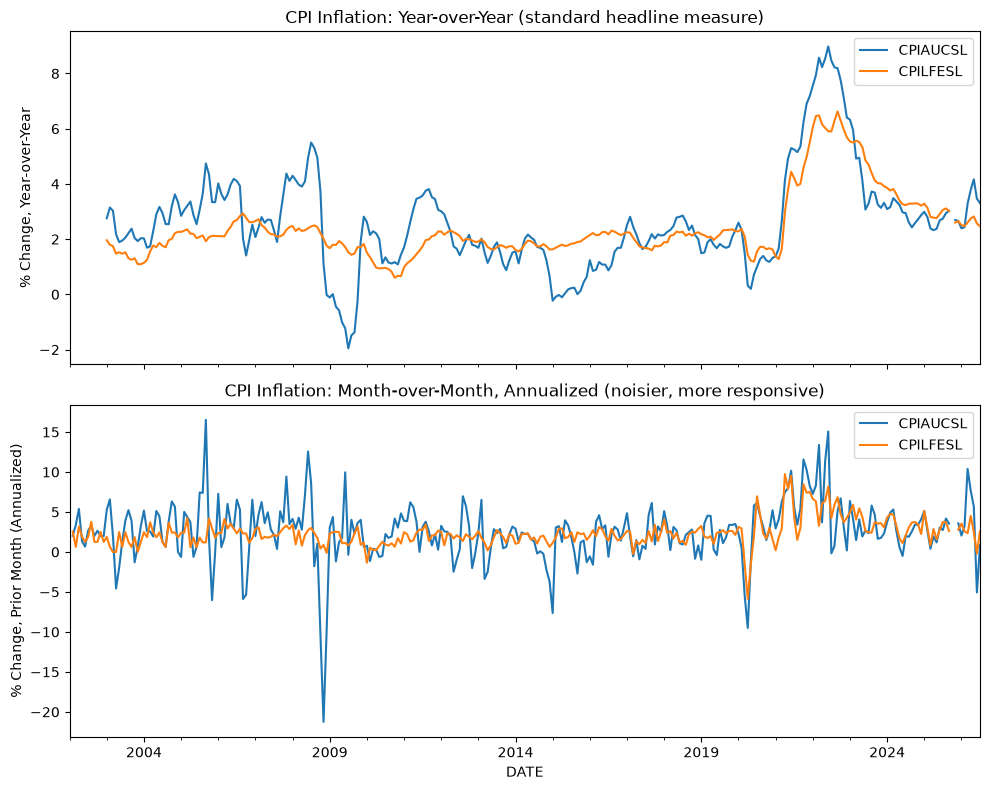

In [6]:
import matplotlib.pyplot as plt

# Year-over-year (YoY): percent change from the same month one year ago -- the standard
# headline measure quoted in the financial press and by the Fed/BLS.
inflation_yoy = 100 * cpi.pct_change(12)

# Annualized month-over-month (MoM): percent change from the previous month, annualized.
# More responsive to recent momentum, but much noisier.
inflation_mom_annualized = 12 * 100 * cpi.pct_change()

inflation_yoy.tail(10)

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

inflation_yoy.plot(ax=axes[0])
axes[0].set_ylabel('% Change, Year-over-Year')
axes[0].set_title('CPI Inflation: Year-over-Year (standard headline measure)')

inflation_mom_annualized.plot(ax=axes[1])
axes[1].set_ylabel('% Change, Prior Month (Annualized)')
axes[1].set_title('CPI Inflation: Month-over-Month, Annualized (noisier, more responsive)')

fig.tight_layout()
plt.show()

## Downloading data from Kenneth French's Library

Ken French maintains an important [database](https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/data_library.html) of returns on different (mostly equity) portfolios. This database is used very frequently in academic asset-pricing research, and we will use it for several examples in the coming weeks.

The following illustrates how to pull data from the French library using `pandas_datareader`. There is a convenient `get_available_datasets` function for this library that returns all possible datasets as a list. Below we print out the first 20 of these.

In [7]:
from pandas_datareader.famafrench import get_available_datasets

frenchsets = get_available_datasets()
print(frenchsets[0:20])

['F-F_Research_Data_Factors', 'F-F_Research_Data_Factors_weekly', 'F-F_Research_Data_Factors_daily', 'F-F_Research_Data_5_Factors_2x3', 'F-F_Research_Data_5_Factors_2x3_daily', 'Portfolios_Formed_on_ME', 'Portfolios_Formed_on_ME_Wout_Div', 'Portfolios_Formed_on_ME_Daily', 'Portfolios_Formed_on_BE-ME', 'Portfolios_Formed_on_BE-ME_Wout_Div', 'Portfolios_Formed_on_BE-ME_Daily', 'Portfolios_Formed_on_OP', 'Portfolios_Formed_on_OP_Wout_Div', 'Portfolios_Formed_on_OP_Daily', 'Portfolios_Formed_on_INV', 'Portfolios_Formed_on_INV_Wout_Div', 'Portfolios_Formed_on_INV_Daily', '6_Portfolios_2x3', '6_Portfolios_2x3_Wout_Div', '6_Portfolios_2x3_weekly']


As you can see, there are many different datasets of portfolio returns, sorted on characteristics such as size (market equity, "ME"), book-market ("BE-ME"), profitability, investment, momentum, industry membership, and so forth. The series are also available at different frequencies, including daily, weekly, monthly, etc.

Below is a simple example of pulling data from the French library: the Fama-French 3 factors (Mkt-RF, SMB, HML) plus a proxy for the risk-free rate, at the *daily* frequency.

In [8]:
fffactors = web.DataReader('F-F_Research_Data_Factors_daily', 'famafrench')

print(fffactors['DESCR'])

fffactors[0].tail(10)

F-F Research Data Factors daily
-------------------------------

This file was created by using the 202607 CRSP database. The Tbill return is the simple daily rate that, over the number of trading days compounds to 1-month TBill rate. The 1-month TBill rate data until 202405 are from Ibbotson Associates. Starting from 202406, the 1-month TBill rate is from ICE BofA US 1-Month Treasury Bill Index. Copyright 2026 Eugene F. Fama and Kenneth R. French

  0 : (1229 rows x 4 cols)


,Mkt-RF,SMB,HML,RF
Date,,,,
2026-07-20,-0.30,-0.45,-0.22,0.02
2026-07-21,0.86,-0.12,0.24,0.02
2026-07-22,-0.18,-1.08,1.21,0.02
2026-07-23,-1.37,-0.08,0.31,0.02
2026-07-24,0.00,-0.12,0.66,0.02
2026-07-27,0.15,0.80,-0.84,0.02
2026-07-28,0.27,0.43,0.45,0.02
2026-07-29,-1.52,0.31,0.31,0.02
2026-07-30,1.59,-0.70,-1.36,0.02


## Downloading data from WRDS: CRSP and Compustat

The data sources covered above are all public. There are also several subscription-based databases that are essential for research-quality work in asset pricing and corporate finance. The two most important are:

1. CRSP ([Center for Research in Security Prices](https://www.crsp.org/))
2. [Compustat](https://www.marketplace.spglobal.com/en/datasets/compustat-financials-(8))

CRSP is a database of security prices and related information, including stock events such as dividend distributions. It is the standard source for US stock return data in academic studies.

Compustat is a database of accounting information (and some stock information) for US and global companies. It is the standard source for firm-level accounting data in academic studies.

Neither of these data sources is public, and subscriptions are quite costly. The Pamplin College of Business / finance department has a subscription to Wharton Research Data Services (WRDS) that includes CRSP and Compustat data (as well as other data sources). I am setting up a classroom WRDS account so that you'll have direct access -- I'll share login details once it's ready.

Below is an example of the kind of data that can be pulled from WRDS, using Compustat. The code opens a WRDS connection and imports a number of fields from the Compustat database, then constructs firm-level book equity, sales, and EBIT (earnings before interest and taxes) for each firm-year, following the book-equity construction in Daniel and Titman (JF 1997).

**Note:** the code below has not been executed in this notebook -- running it will prompt you for your WRDS username and password, and needs a live WRDS connection (your classroom account, or individual credentials if you already have WRDS access).

In [ ]:
%pip install wrds
import wrds

# WRDS connection -- this will prompt for your WRDS username and password
conn = wrds.Connection()

###################
# Compustat Block #
###################

comp = conn.raw_sql("""
                    select gvkey, datadate, cusip, sale, ebit,
                    sich, seq, pstkrv, pstkl, pstk, txdb, itcb
                    from comp.funda
                    where indfmt='INDL'
                    and datafmt='STD'
                    and popsrc='D'
                    and consol='C'
                    and datadate >= '01/01/1970'
                    """)

comp['datadate'] = pd.to_datetime(comp['datadate'])  # convert datadate to date fmt
comp['year'] = comp['datadate'].dt.year
# Next line retains only records with positive book equity (seq)
comp = comp[comp['seq'] > 0]

# create a measure of preferred stock:
# 1st choice: Preferred stock - Redemption Value
# 2nd choice: Preferred stock - Liquidating Value
# 3rd choice: Preferred stock - Carrying Value, Stock (Capital) - Total
comp['pref'] = np.where(comp['pstkrv'].isnull(), comp['pstkl'], comp['pstkrv'])
comp['pref'] = np.where(comp['pref'].isnull(), comp['pstk'], comp['pref'])
comp['pref'] = np.where(comp['pref'].isnull(), 0, comp['pref'])

# fill in missing values for deferred taxes and investment tax credit
comp['txdb'] = comp['txdb'].fillna(0)
comp['itcb'] = comp['itcb'].fillna(0)

# create firm-level book equity
# Daniel and Titman (JF 1997):
# BE = stockholders' equity + deferred taxes + investment tax credit - Preferred Stock
comp['be'] = comp['seq'] + comp['txdb'] + comp['itcb'] - comp['pref']

# keep only records with non-negative book equity
comp = comp[comp['be'] >= 0]
# Next line pitches out extra stuff used to compute be above
comp = comp[['gvkey', 'datadate', 'year', 'be', 'sale', 'ebit']]

comp.head(50)

In [ ]:
# Create a "panel" dataset consisting of firm-level EBIT across years.

# Data comes back in "long" format, which is hard to digest -- let's reshape it:
comp2 = comp.pivot_table(values='ebit', index='gvkey', columns=['year'])
comp2.head(75)

# Now we can see EBIT across firms and time

## Takeaways

- Excel files can be read directly into pandas with `pd.read_excel`, including picking a specific worksheet via `sheet_name` -- useful for datasets like Goyal-Welch that ship multiple frequencies (monthly/quarterly/annual) in one workbook.
- `pandas_datareader` gives one-line access to FRED (macro series like GDP and CPI) and Kenneth French's data library (portfolio returns and factors), which saves you from manually downloading and reformatting files and makes your data pull reproducible from code.
- Levels (GDP, CPI) are usually less directly useful than growth rates. `pct_change()` converts a level series to a growth/inflation rate in one line, but you need to be careful about scaling (percent vs. decimal) and annualizing, and about how a series' date label maps to the period it covers.
- CRSP and Compustat, accessed through WRDS, are not free -- unlike everything else in this notebook, they require a subscription and login credentials. This course provides access via a classroom WRDS account.

**Where this goes next.** The Goyal-Welch dataset resurfaces in `Equity_Premium_Inference.ipynb`, where we use it to study whether the equity premium is predictable. The Fama-French portfolio and factor data resurface in `CAPM_BivariateRegression.ipynb` and in later notebooks on multifactor models.